# EDA reproducible — LaLiga

El análisis consume exclusivamente `data/processed/laliga_matches_clean.csv`, generado por `notebooks/00_laliga_preprocessing.ipynb` y el pipeline de `src/data/`. El target provisional es `result_ft` (H/D/A). No se entrenan modelos ni se crean particiones.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.laliga_loader import audit_dataset, load_processed_dataset
from src.data.laliga_eda import build_data_dictionary, calculate_eda_metrics
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'laliga_matches_clean.csv'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
matches = load_processed_dataset(DATA_PATH)
metrics = calculate_eda_metrics(matches)
pd.Series(audit_dataset(matches), name='valor').to_frame()

,valor
rows,11944
columns,54
season_count,31
date_min,1995-09-02
date_max,2026-05-24
duplicate_rows,0
duplicate_match_ids,0
missing_target,0
missing_half_time_rows,2
full_time_result_inconsistencies,0


## Calidad, nulos y duplicados

La auditoría exige identificadores únicos, target completo y coherencia entre resultado y marcador final. Los nulos restantes se describen por columna y se interpretan según su mecanismo de captura.

In [2]:
missing = pd.DataFrame({'nulos': matches.isna().sum(), 'porcentaje': matches.isna().mean()}).sort_values('porcentaje', ascending=False)
missing.loc[missing['nulos'].gt(0)].head(30)

,nulos,porcentaje
asian_handicap_line_open,11568,0.968520
match_time,11564,0.968185
odds_avg_over_2_5_close,11564,0.968185
odds_avg_away_close,11564,0.968185
odds_avg_draw_close,11564,0.968185
odds_avg_over_2_5_open,11564,0.968185
fouls_home,11564,0.968185
odds_avg_home_open,11564,0.968185
odds_avg_away_open,11564,0.968185
odds_avg_draw_open,11564,0.968185


## Distribuciones y target

Se estudian balance, evolución temporal, goles y ventaja local. Estos análisis son descriptivos; no establecen causalidad.

In [3]:
pd.DataFrame({'partidos': pd.Series(metrics['target']['counts']), 'proporción': pd.Series(metrics['target']['shares'])})

,partidos,proporción
H,5641,0.472287
D,3058,0.256028
A,3245,0.271685


## Outliers mediante IQR

Se reportan Q1, Q3, límites y porcentaje de observaciones fuera de rango. Un outlier estadístico no equivale a un error de datos.

In [4]:
pd.DataFrame(metrics['outliers_iqr']).T.sort_values('pct', ascending=False)

,count,pct,lower,upper
red_cards_away,49.0,0.128947,0.0,0.0
red_cards_home,42.0,0.110526,0.0,0.0
home_goals_ft,973.0,0.081463,-0.5,3.5
shots_away,12.0,0.031579,-1.0,23.0
shots_on_target_away,9.0,0.023684,-2.5,9.5
yellow_cards_away,8.0,0.021053,-2.0,6.0
fouls_home,3.0,0.007895,2.5,22.5
shots_home,3.0,0.007895,-0.5,27.5
yellow_cards_home,1.0,0.002632,-2.0,6.0
away_goals_ft,31.0,0.002595,-3.0,5.0


## Diccionario, correlaciones y leakage

La disponibilidad en inferencia se documenta por variable. Goles, tiros, faltas, córners y tarjetas del mismo partido son postevento y deben excluirse de cualquier pipeline prepartido.

In [5]:
dictionary = build_data_dictionary(matches)
dictionary[['column', 'role', 'available_at_inference', 'leakage_risk', 'missing_pct']].head(60)

,column,role,available_at_inference,leakage_risk,missing_pct
0,match_id,identifier,pre_match,none_but_no_predictive_role,0.000000
1,season,candidate_feature,pre_match,none_identified,0.000000
2,match_date,candidate_feature,pre_match,none_identified,0.000000
3,match_time,candidate_feature,pre_match,none_identified,0.968185
4,match_year,candidate_feature,pre_match,none_identified,0.000000
5,match_month,candidate_feature,pre_match,none_identified,0.000000
6,iso_weekday,candidate_feature,pre_match,none_identified,0.000000
7,home_team,candidate_feature,pre_match,none_identified,0.000000
8,away_team,candidate_feature,pre_match,none_identified,0.000000
9,home_goals_ft,excluded,after_match,critical_post_event,0.000000


## Matrices de confusión descriptivas

Se comparan dos reglas fijas: predecir siempre la clase mayoritaria y elegir el favorito según cuotas promedio de apertura. No existe entrenamiento, split ni candidato de modelo.

In [6]:
labels = ['H', 'D', 'A']
display(pd.DataFrame(metrics['target']['majority_confusion_matrix'], index=[f'Real {x}' for x in labels], columns=[f'Pred {x}' for x in labels]))
display(pd.DataFrame(metrics['market_baseline']['confusion_matrix'], index=[f'Real {x}' for x in labels], columns=[f'Favorito {x}' for x in labels]))

,Pred H,Pred D,Pred A
Real H,5641,0,0
Real D,3058,0,0
Real A,3245,0,0


,Favorito H,Favorito D,Favorito A
Real H,160,0,26
Real D,62,0,31
Real A,54,0,47


## Gráficas persistentes e interpretación

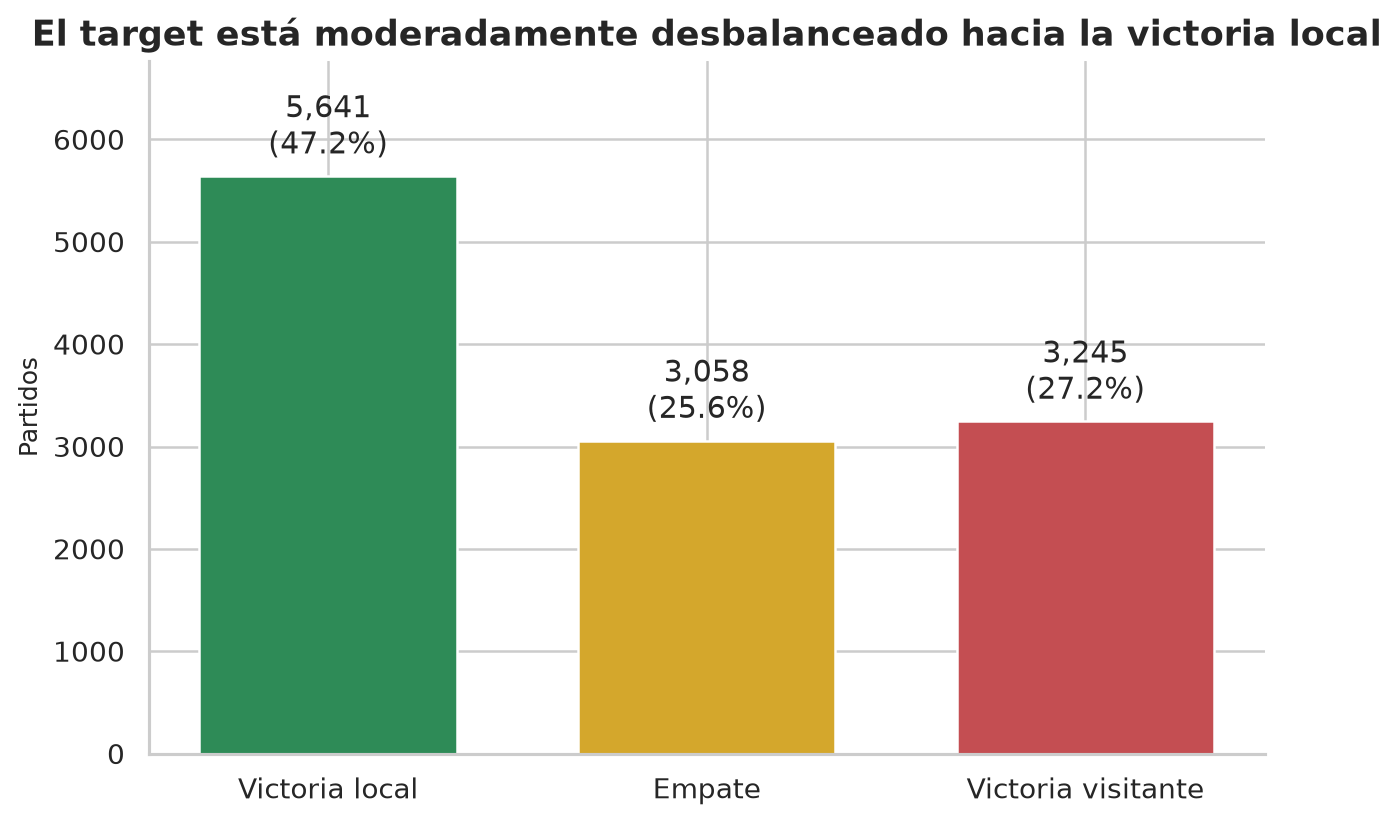

In [7]:
display(Image(filename=str(FIGURES_DIR / '01_target_distribution.png'), width=900))

**Conclusión — `01_target_distribution.png`:** La victoria local es la clase mayoritaria; el desbalance es moderado. La accuracy debe acompañarse de métricas por clase cuando T-0.4 apruebe el protocolo.

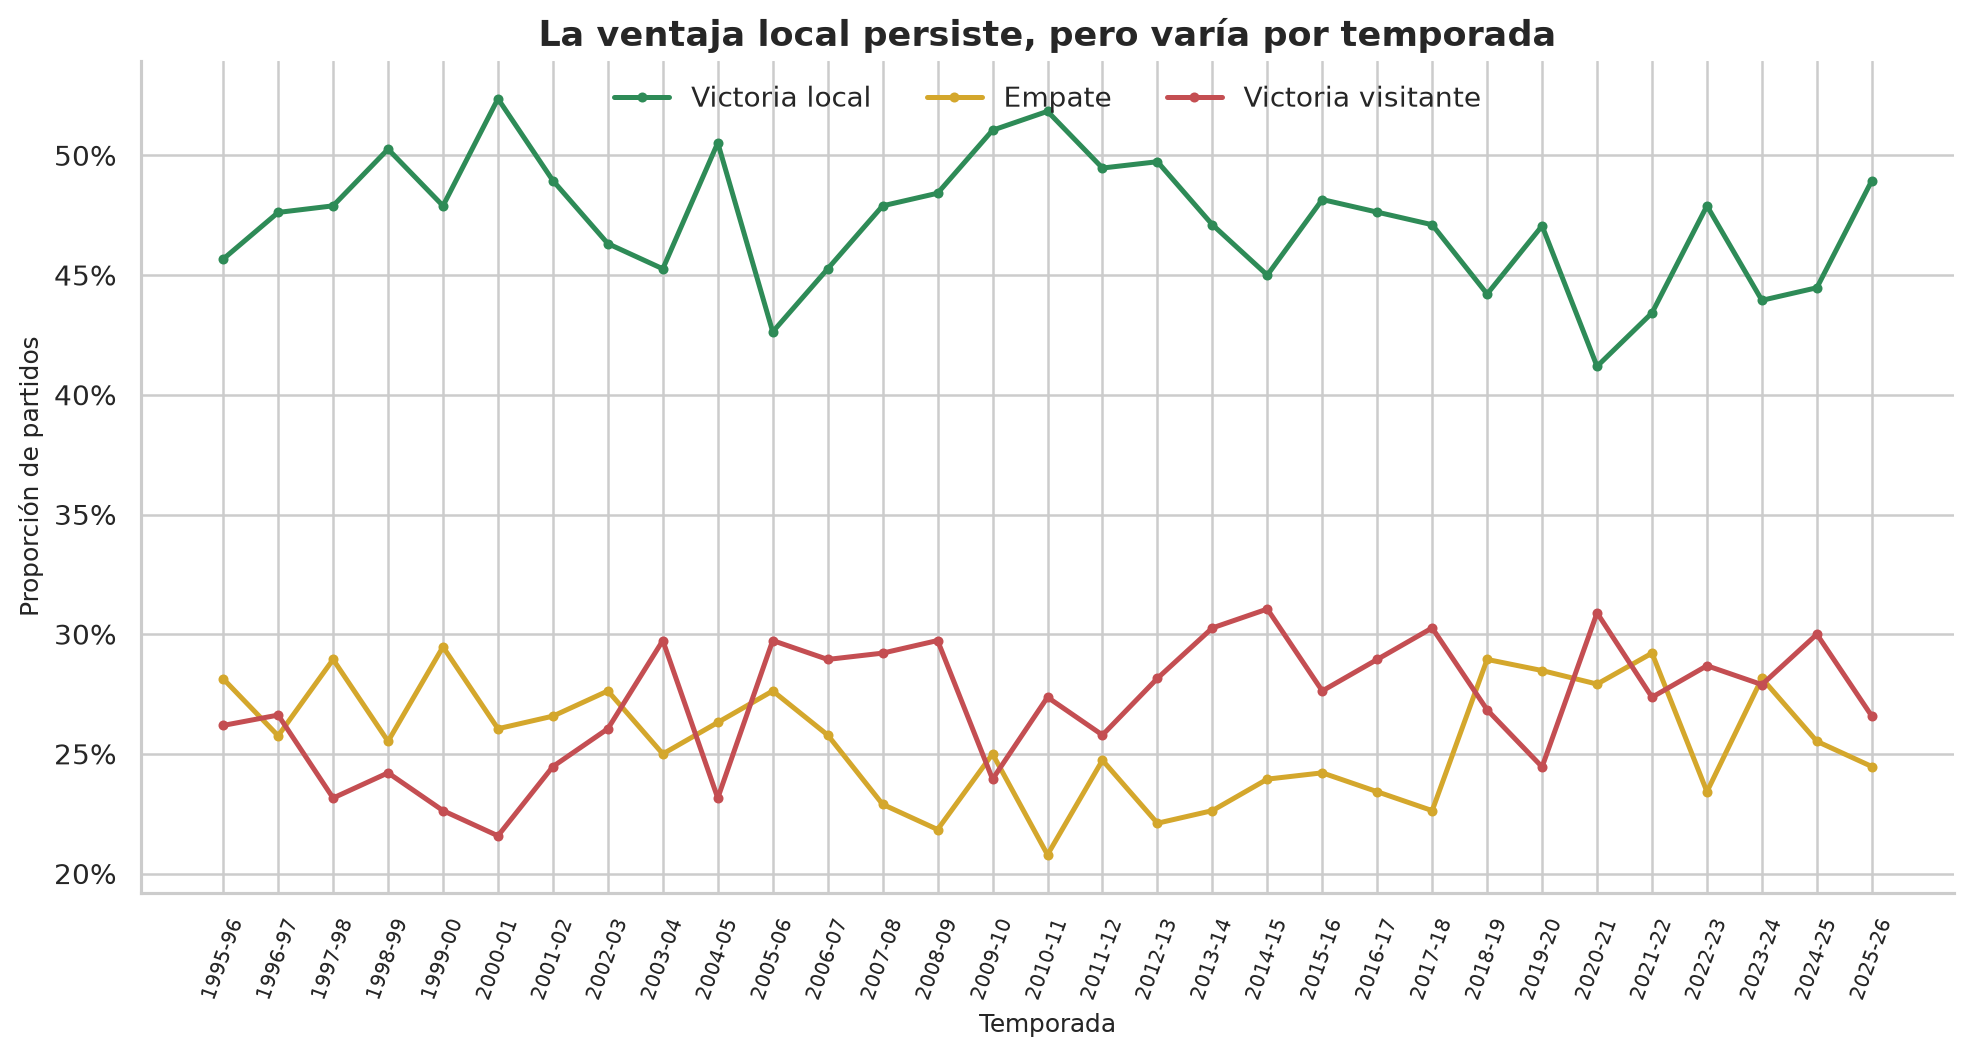

In [8]:
display(Image(filename=str(FIGURES_DIR / '02_target_by_season.png'), width=900))

**Conclusión — `02_target_by_season.png`:** La mezcla H/D/A varía entre temporadas. Aunque la asociación global es baja, el orden temporal debe preservarse para no evaluar con información futura.

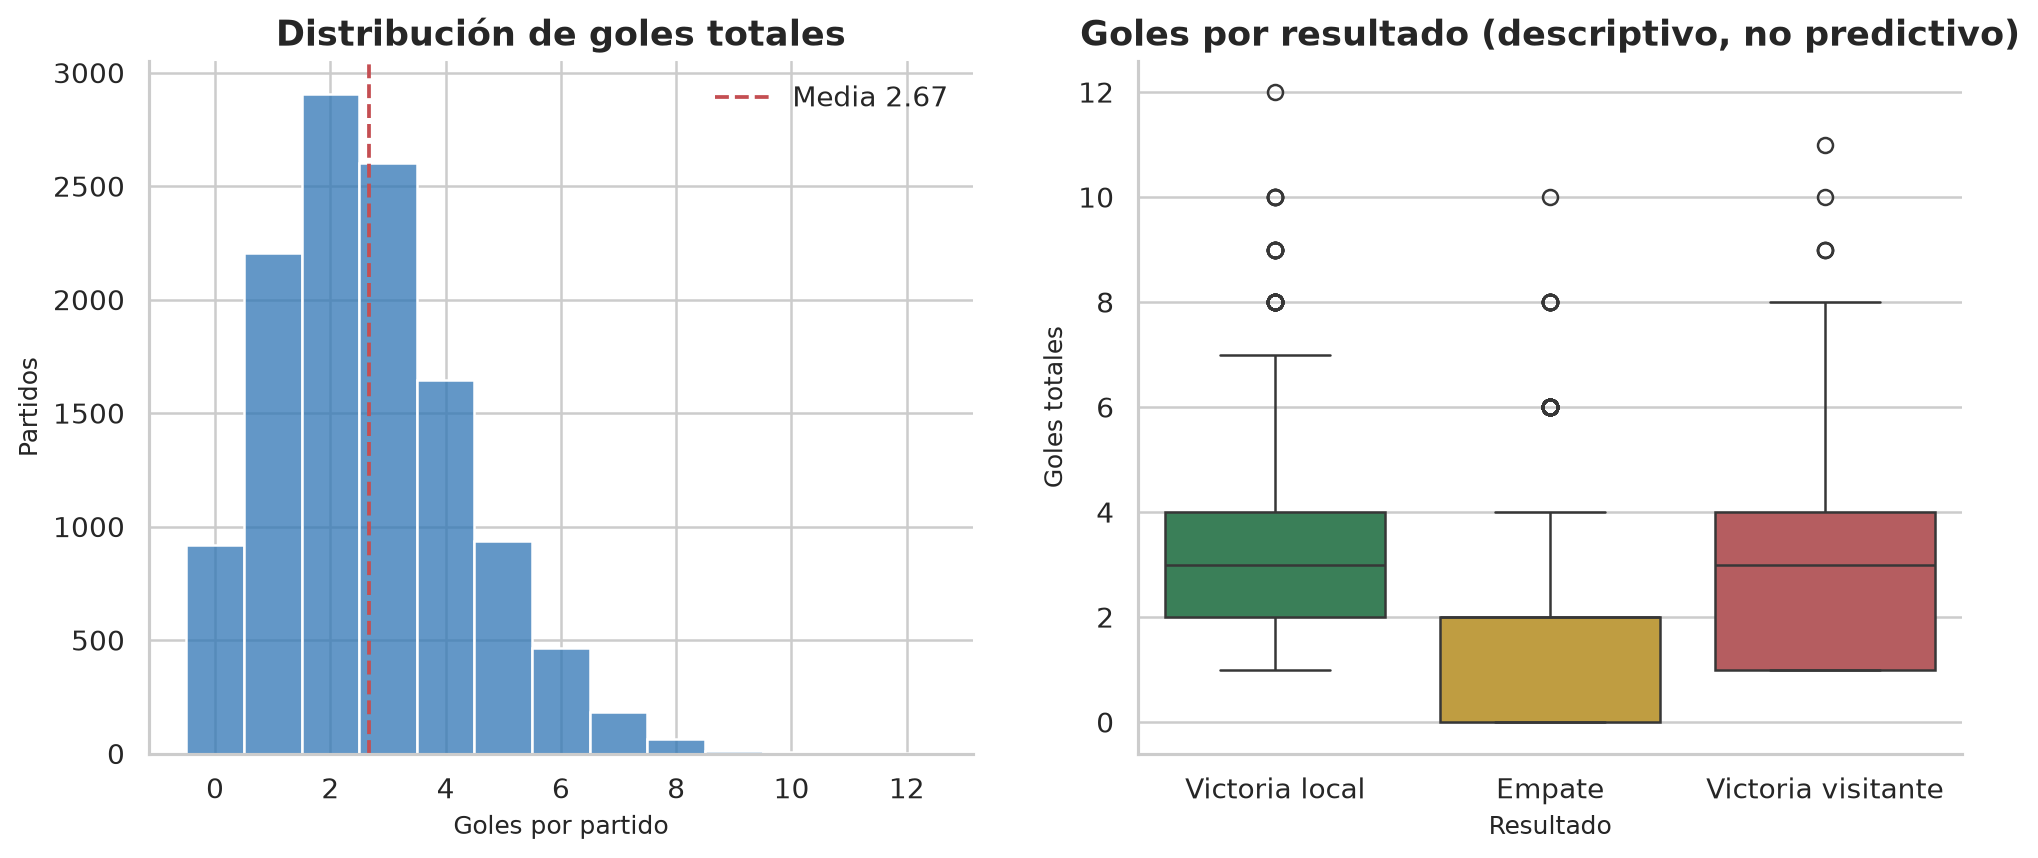

In [9]:
display(Image(filename=str(FIGURES_DIR / '03_goals_distribution.png'), width=900))

**Conclusión — `03_goals_distribution.png`:** Los goles son discretos y presentan cola derecha. Las goleadas son raras pero plausibles, por lo que no se eliminan solo por superar un umbral IQR.

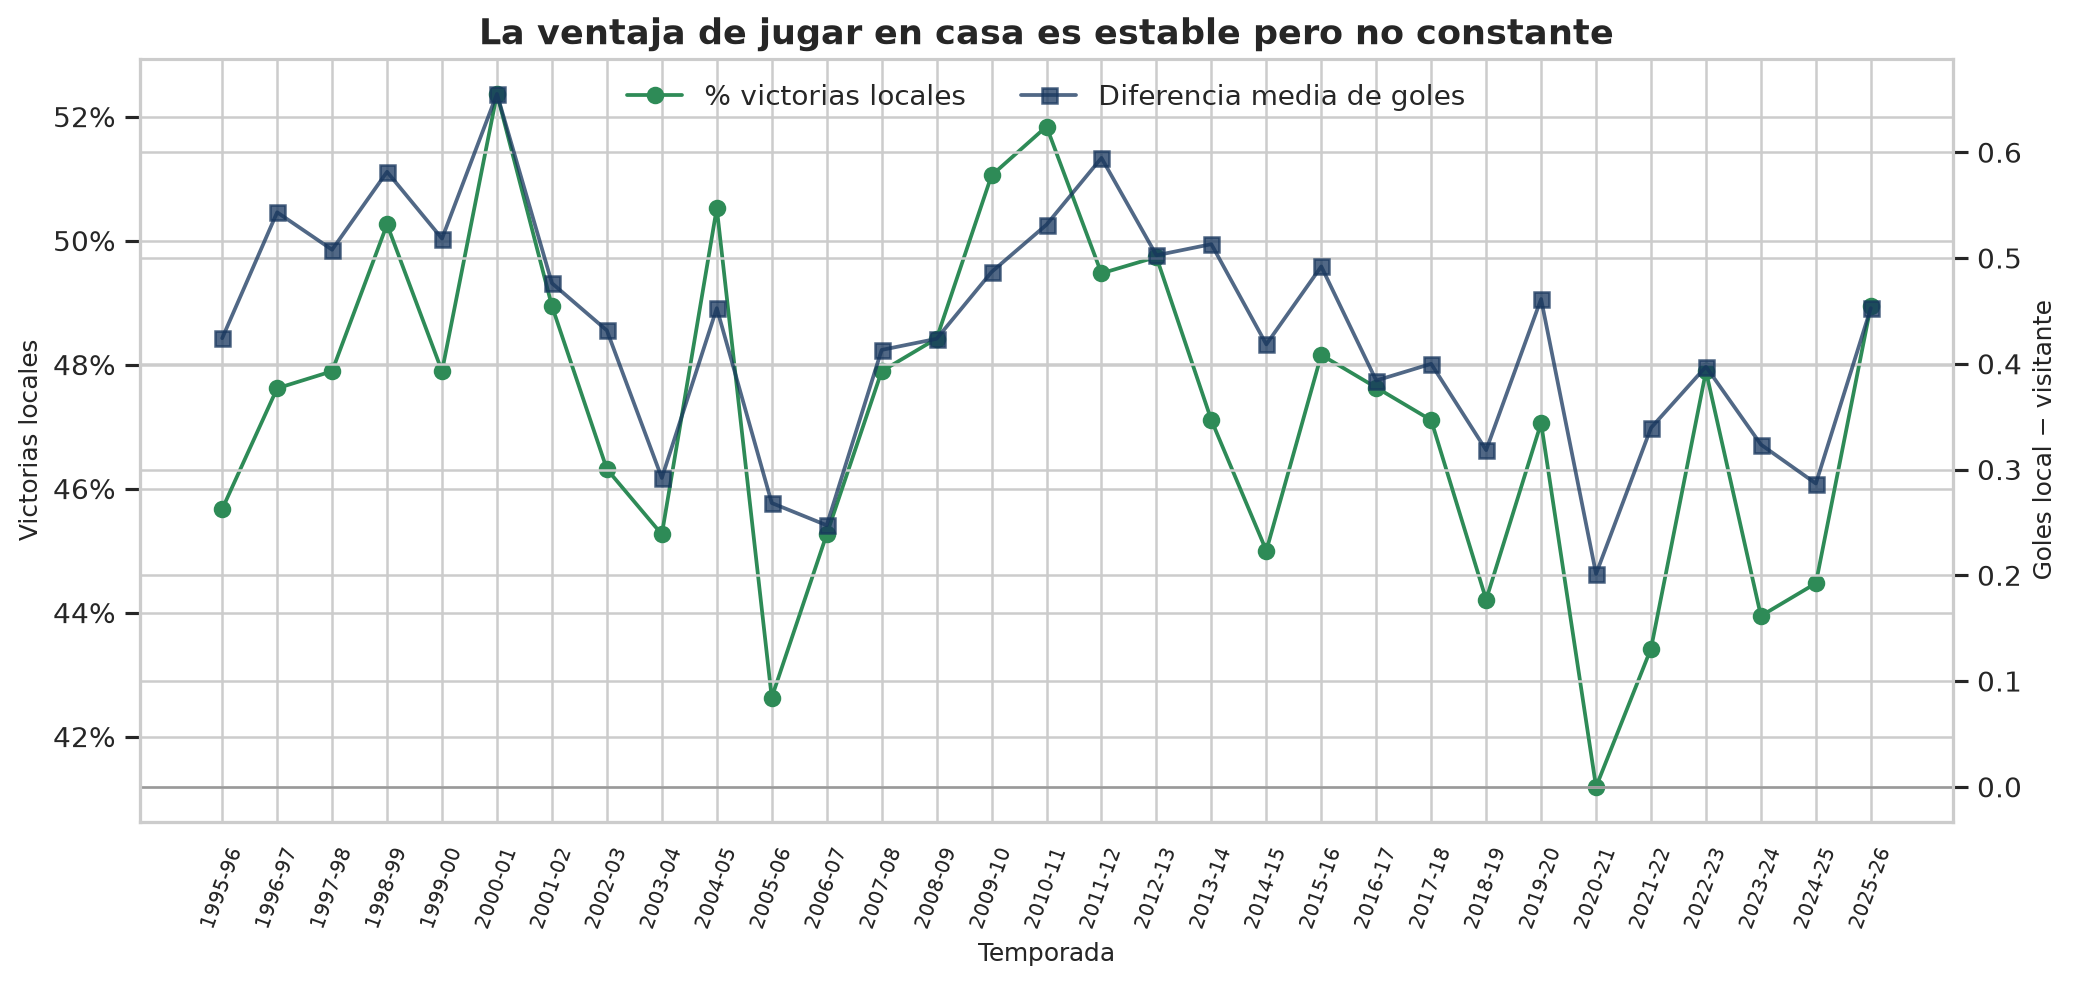

In [10]:
display(Image(filename=str(FIGURES_DIR / '04_home_advantage_trend.png'), width=900))

**Conclusión — `04_home_advantage_trend.png`:** La ventaja local fluctúa con el tiempo. Esto sugiere cambio de distribución y refuerza la necesidad futura de validación cronológica.

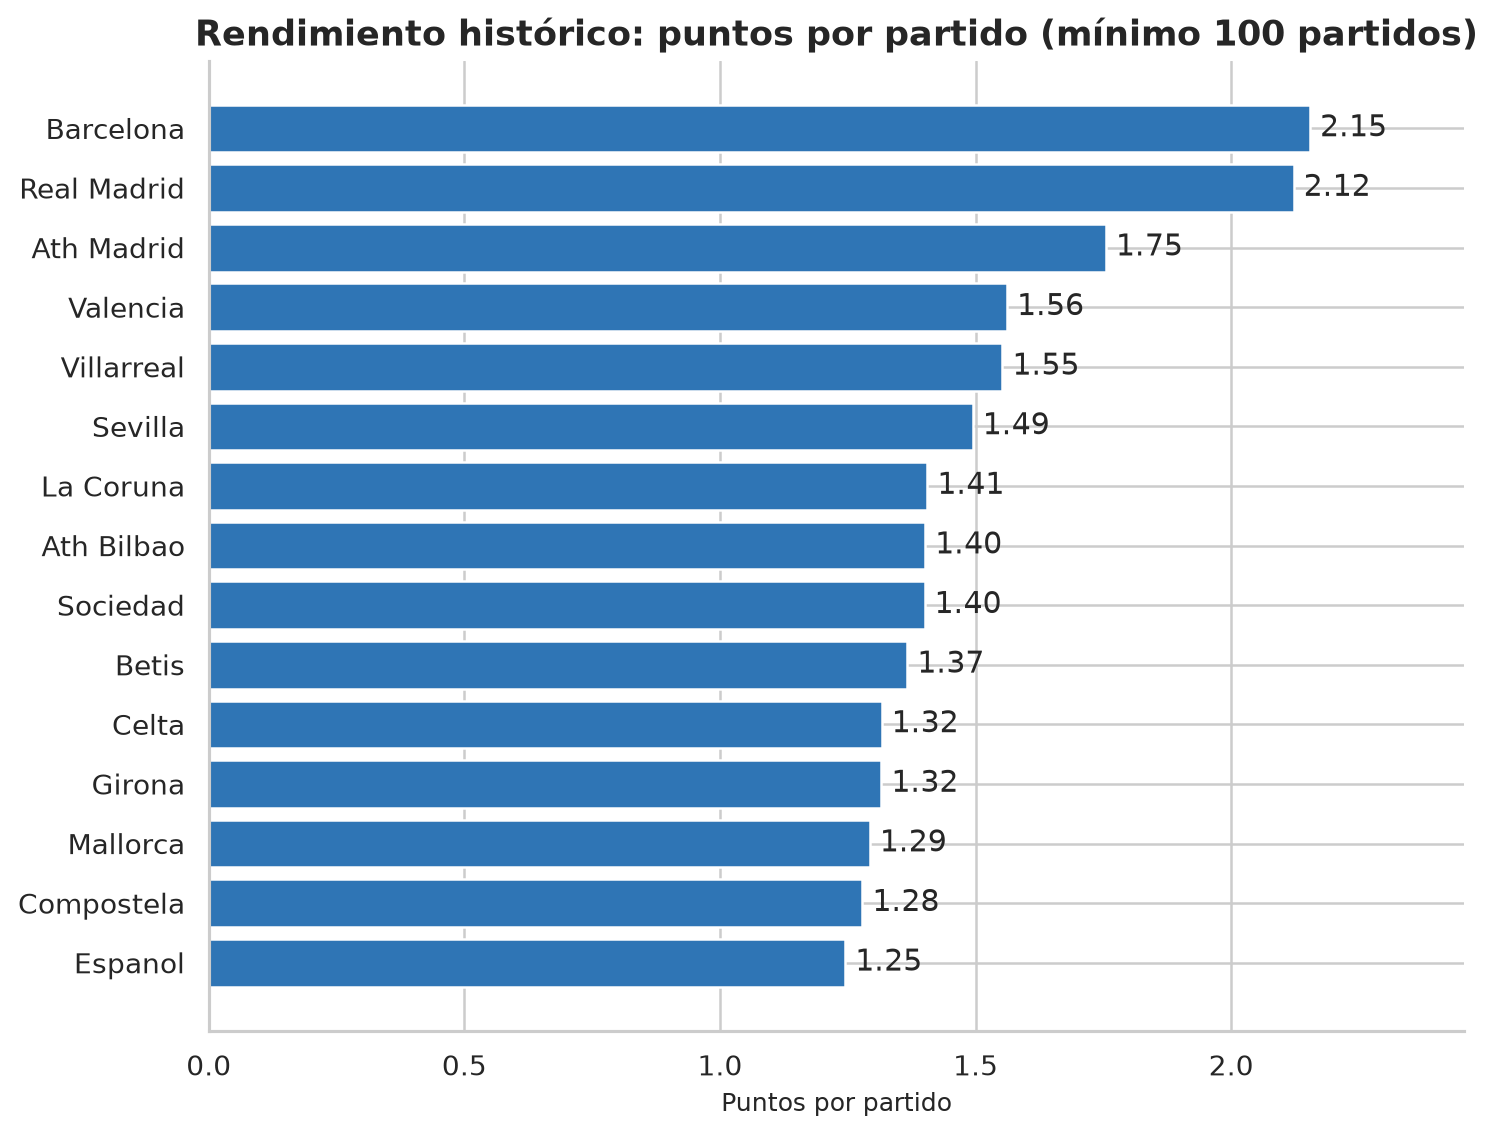

In [11]:
display(Image(filename=str(FIGURES_DIR / '05_team_performance.png'), width=900))

**Conclusión — `05_team_performance.png`:** Los equipos muestran diferencias históricas, pero su identidad bruta puede generalizar mal ante ascensos/descensos; ratings y forma pasada serían alternativas más robustas.

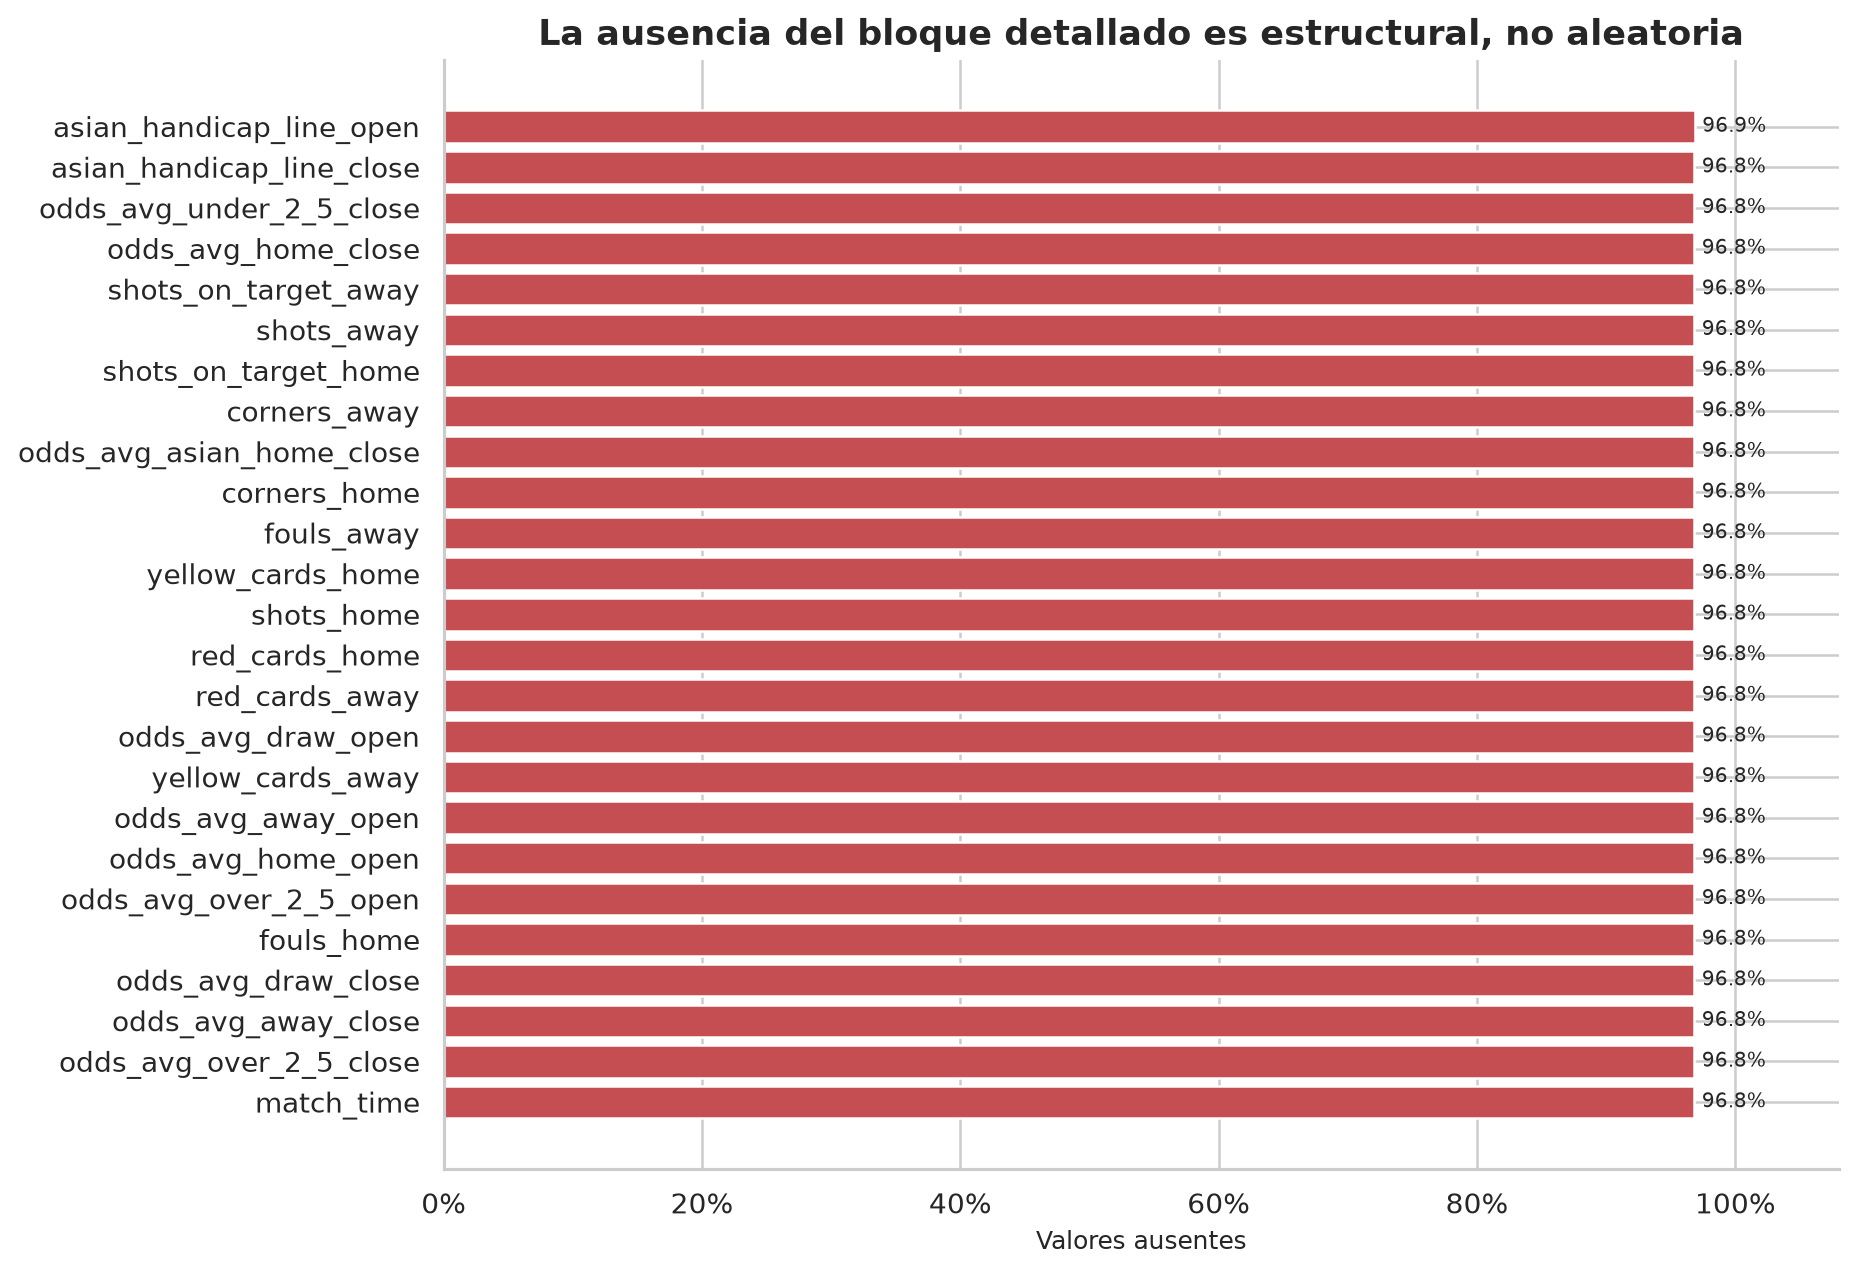

In [12]:
display(Image(filename=str(FIGURES_DIR / '06_missingness_profile.png'), width=900))

**Conclusión — `06_missingness_profile.png`:** Los nulos se concentran en estadísticas disponibles solo en 2025/26. Son estructurales y no deben imputarse sobre temporadas que nunca capturaron esas variables.

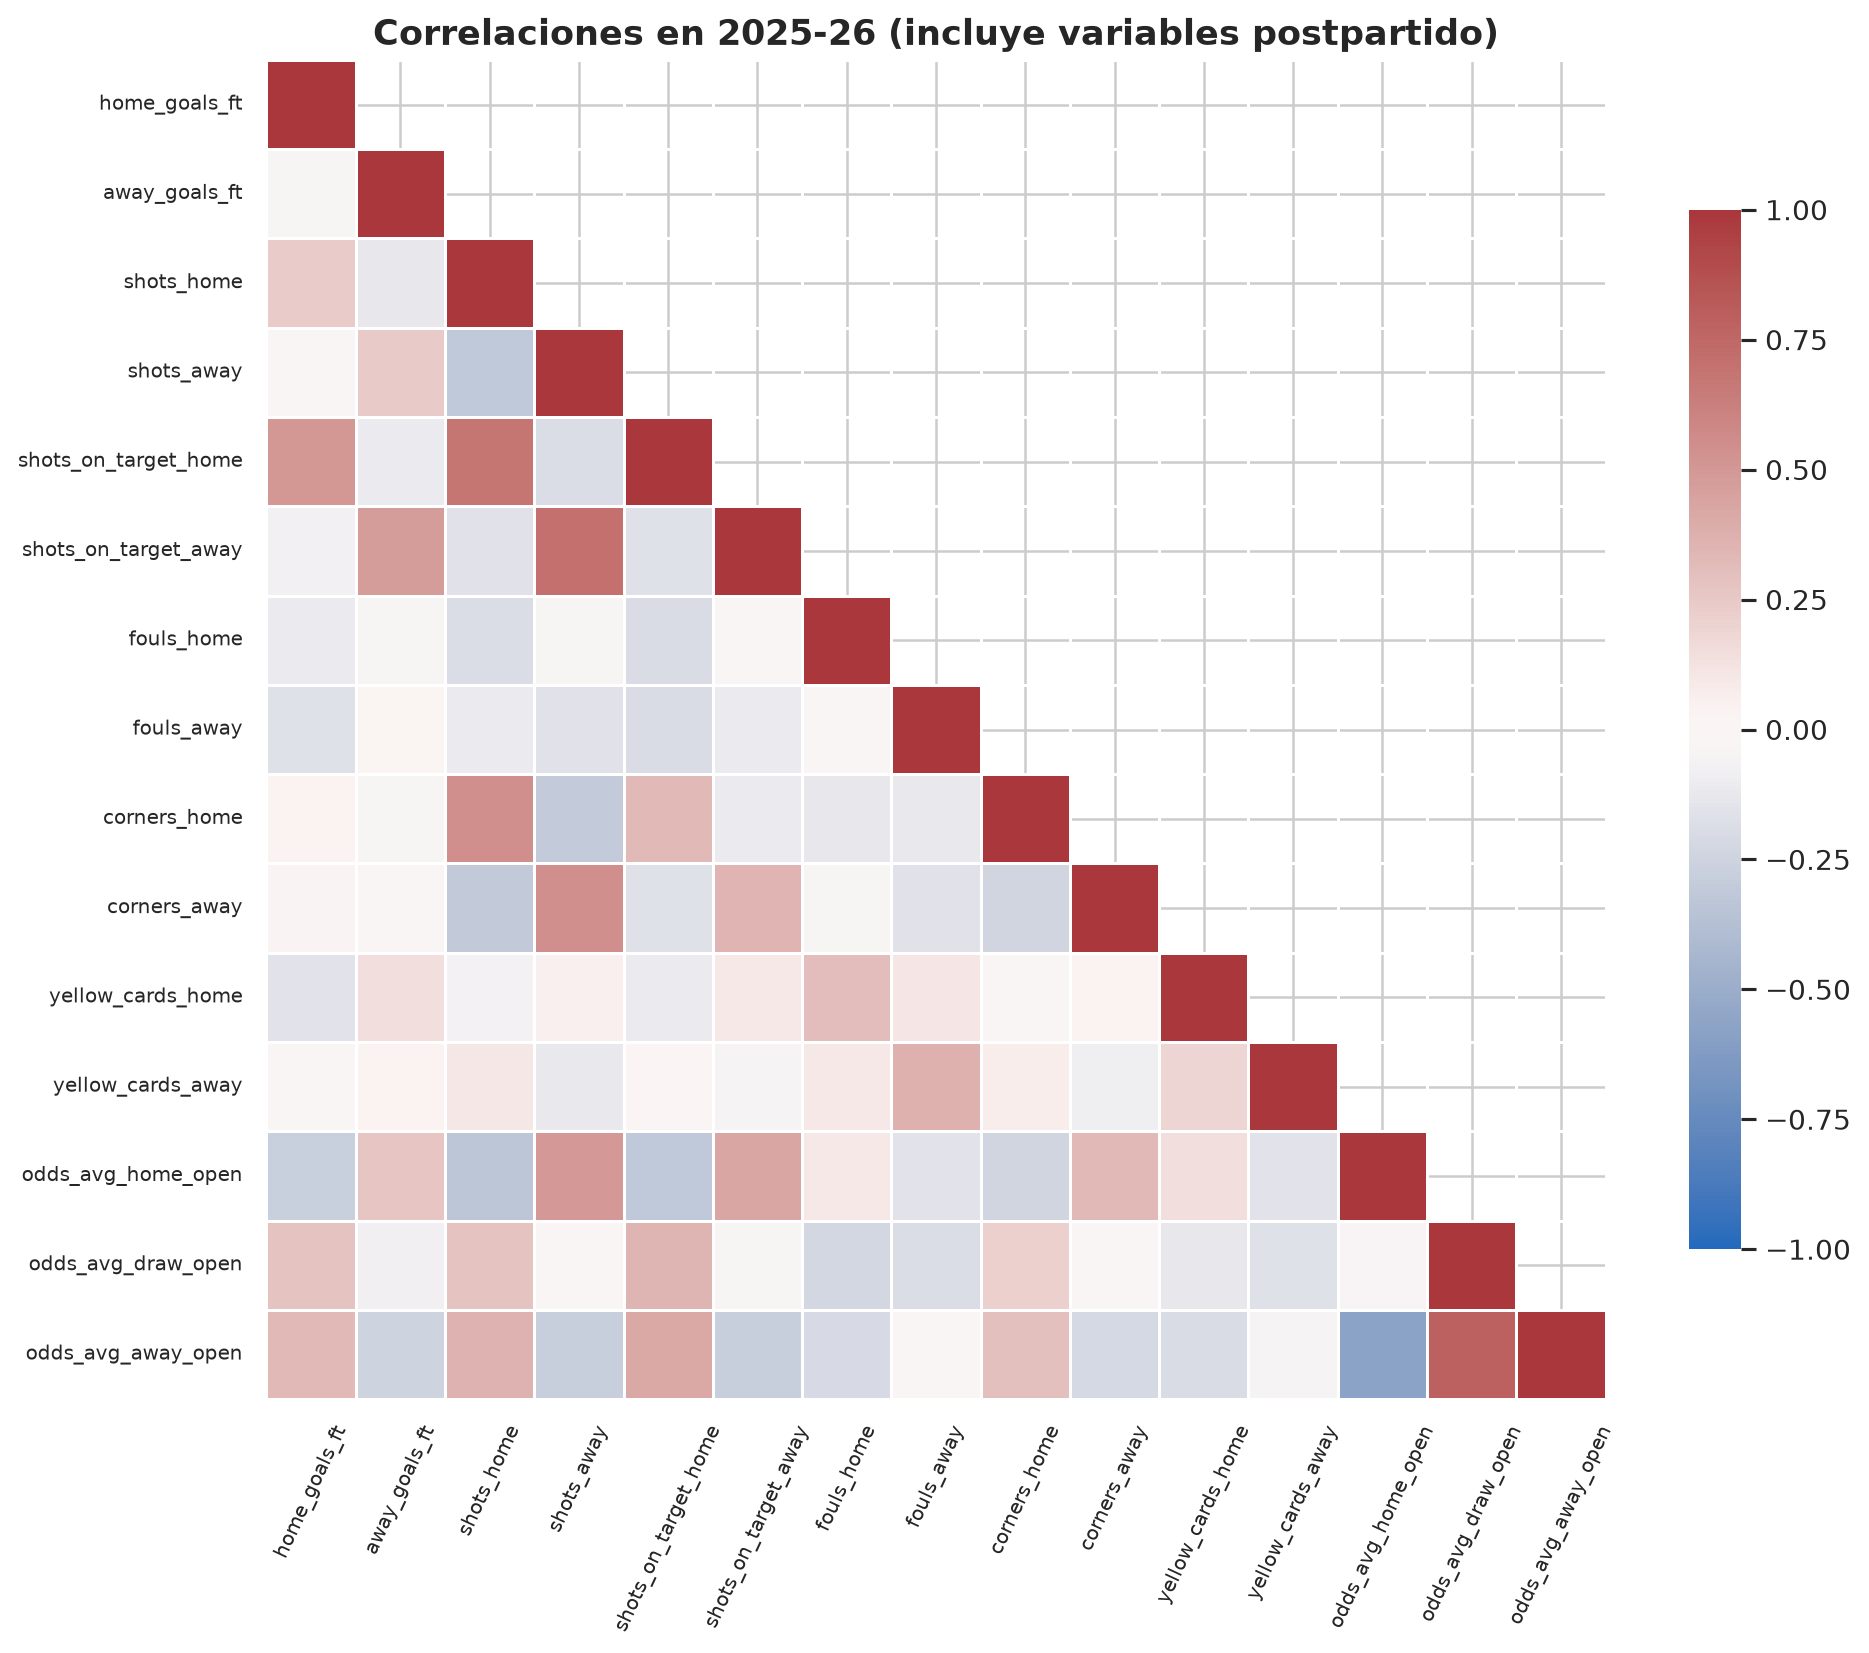

In [13]:
display(Image(filename=str(FIGURES_DIR / '07_detailed_correlation_heatmap.png'), width=900))

**Conclusión — `07_detailed_correlation_heatmap.png`:** Tiros y tiros a puerta se correlacionan con goles, pero ocurren durante el partido. Esta señal es descriptiva y causaría leakage en una predicción prepartido.

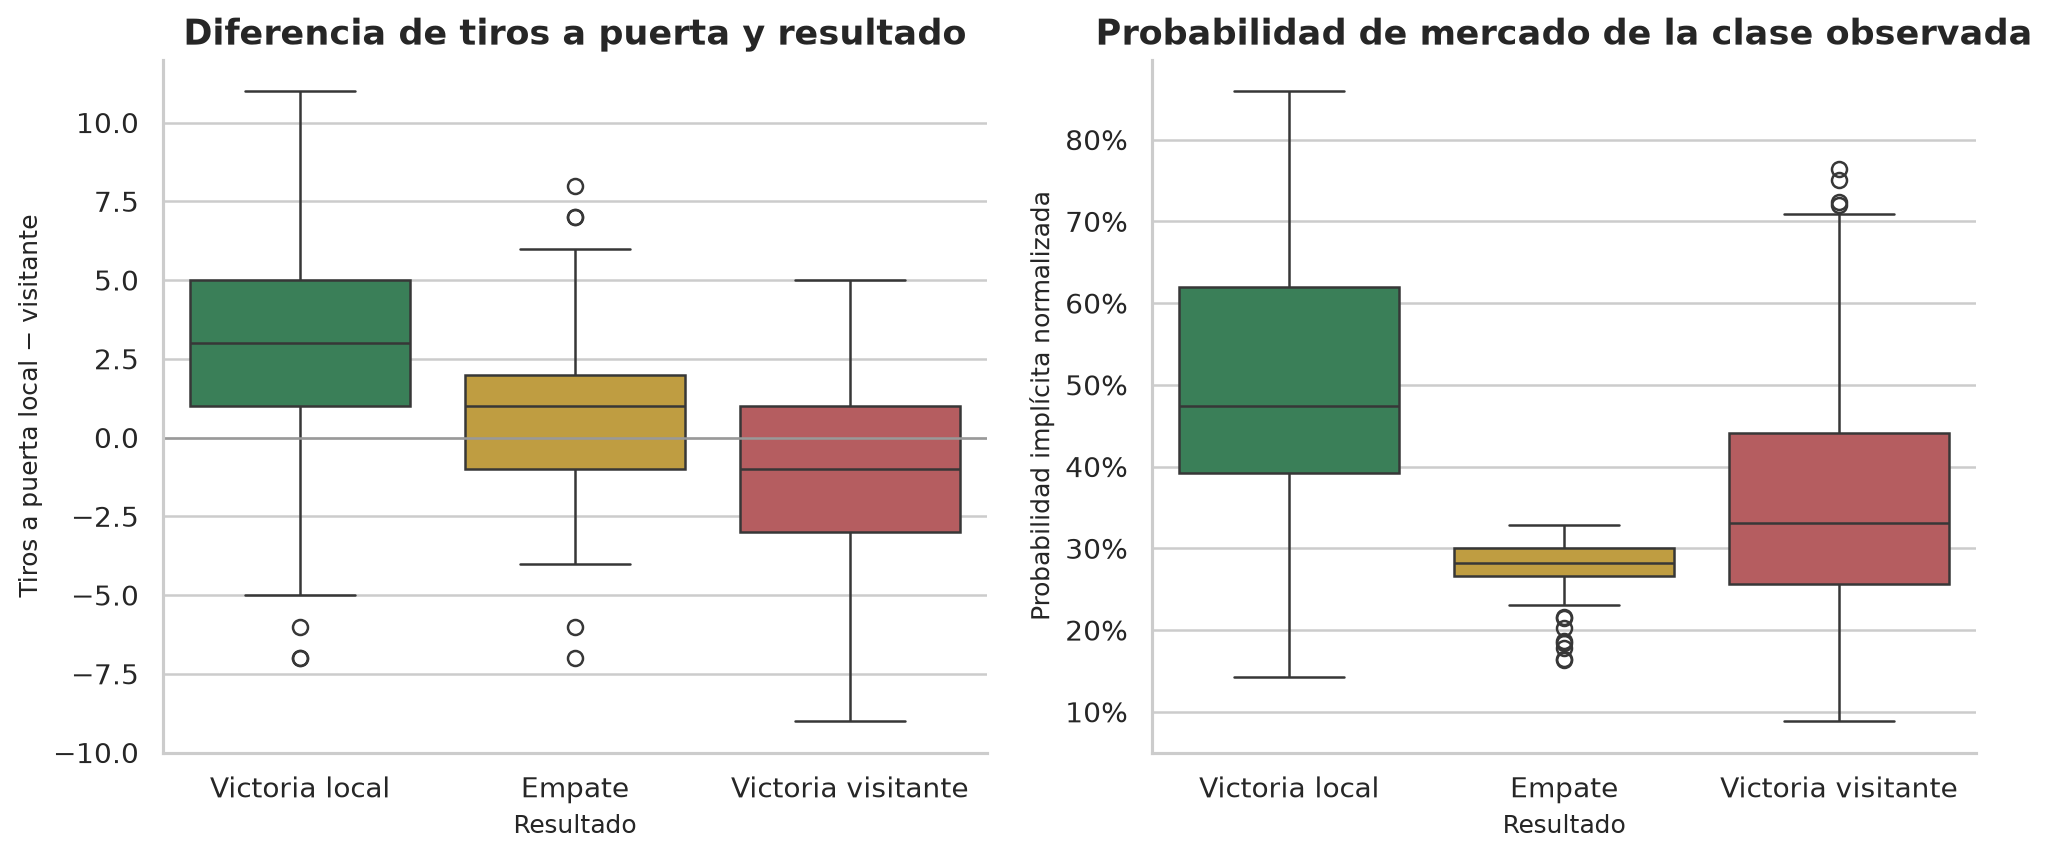

In [14]:
display(Image(filename=str(FIGURES_DIR / '08_relationships_with_target.png'), width=900))

**Conclusión — `08_relationships_with_target.png`:** Las relaciones con el target confirman señal en cuotas y estadísticas postpartido. Solo las variables disponibles antes del encuentro podrían evaluarse como features.

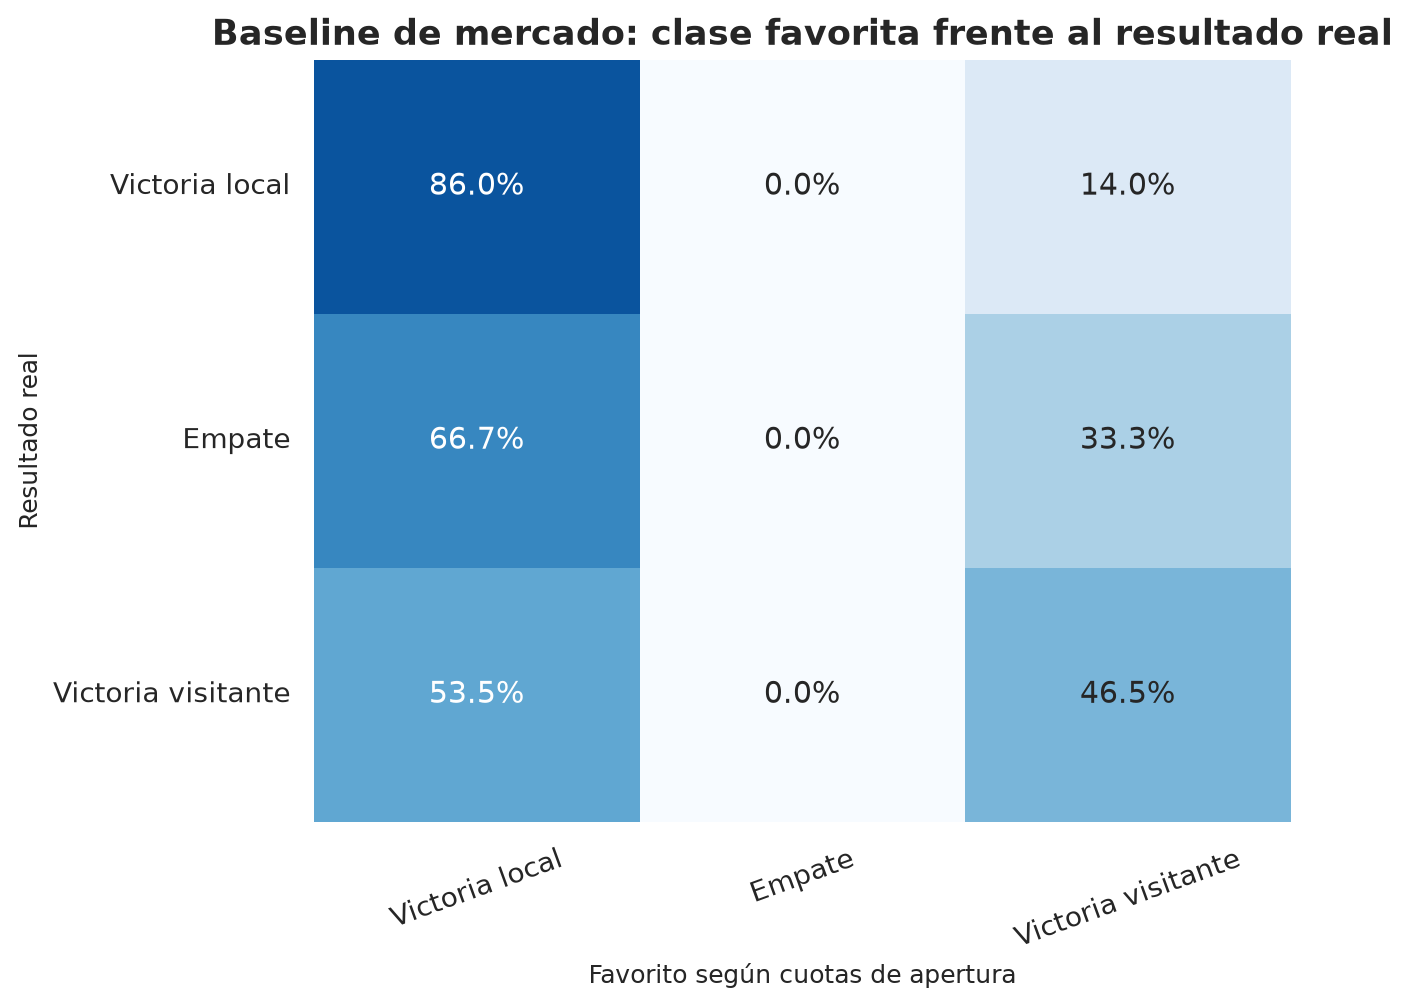

In [15]:
display(Image(filename=str(FIGURES_DIR / '09_market_baseline_confusion.png'), width=900))

**Conclusión — `09_market_baseline_confusion.png`:** La regla del favorito de apertura conserva cierta señal, pero falla especialmente en empates. Es una referencia descriptiva sobre 2025/26, no un modelo ni una métrica final.

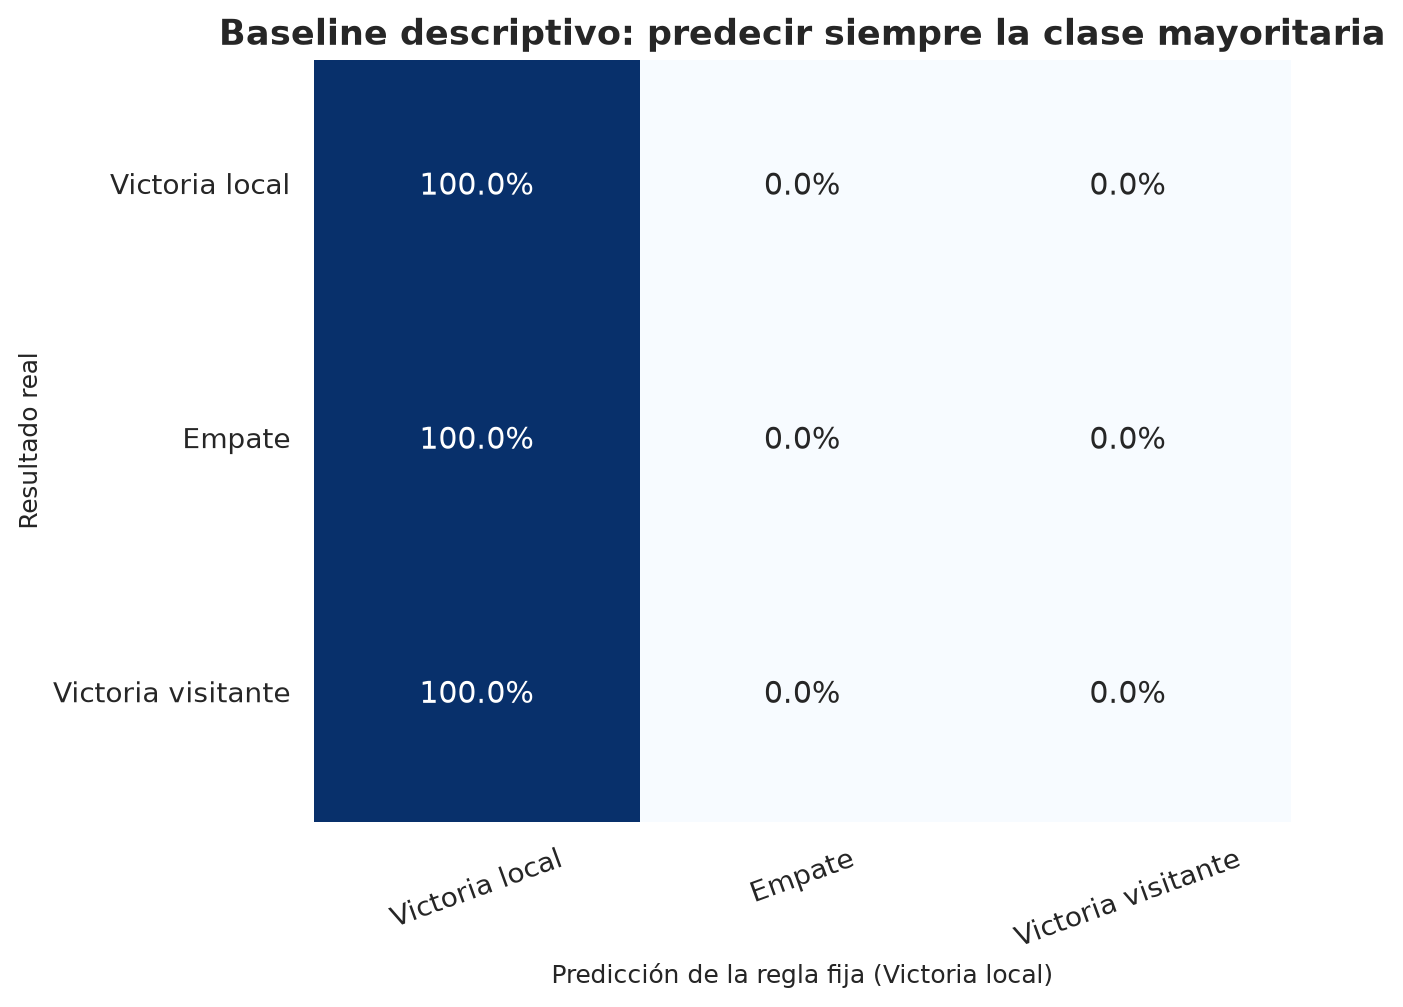

In [16]:
display(Image(filename=str(FIGURES_DIR / '10_majority_baseline_confusion.png'), width=900))

**Conclusión — `10_majority_baseline_confusion.png`:** Predecir siempre H consigue una accuracy aparente aceptable pero recall cero en D y A. La matriz evidencia por qué una sola métrica agregada sería insuficiente.

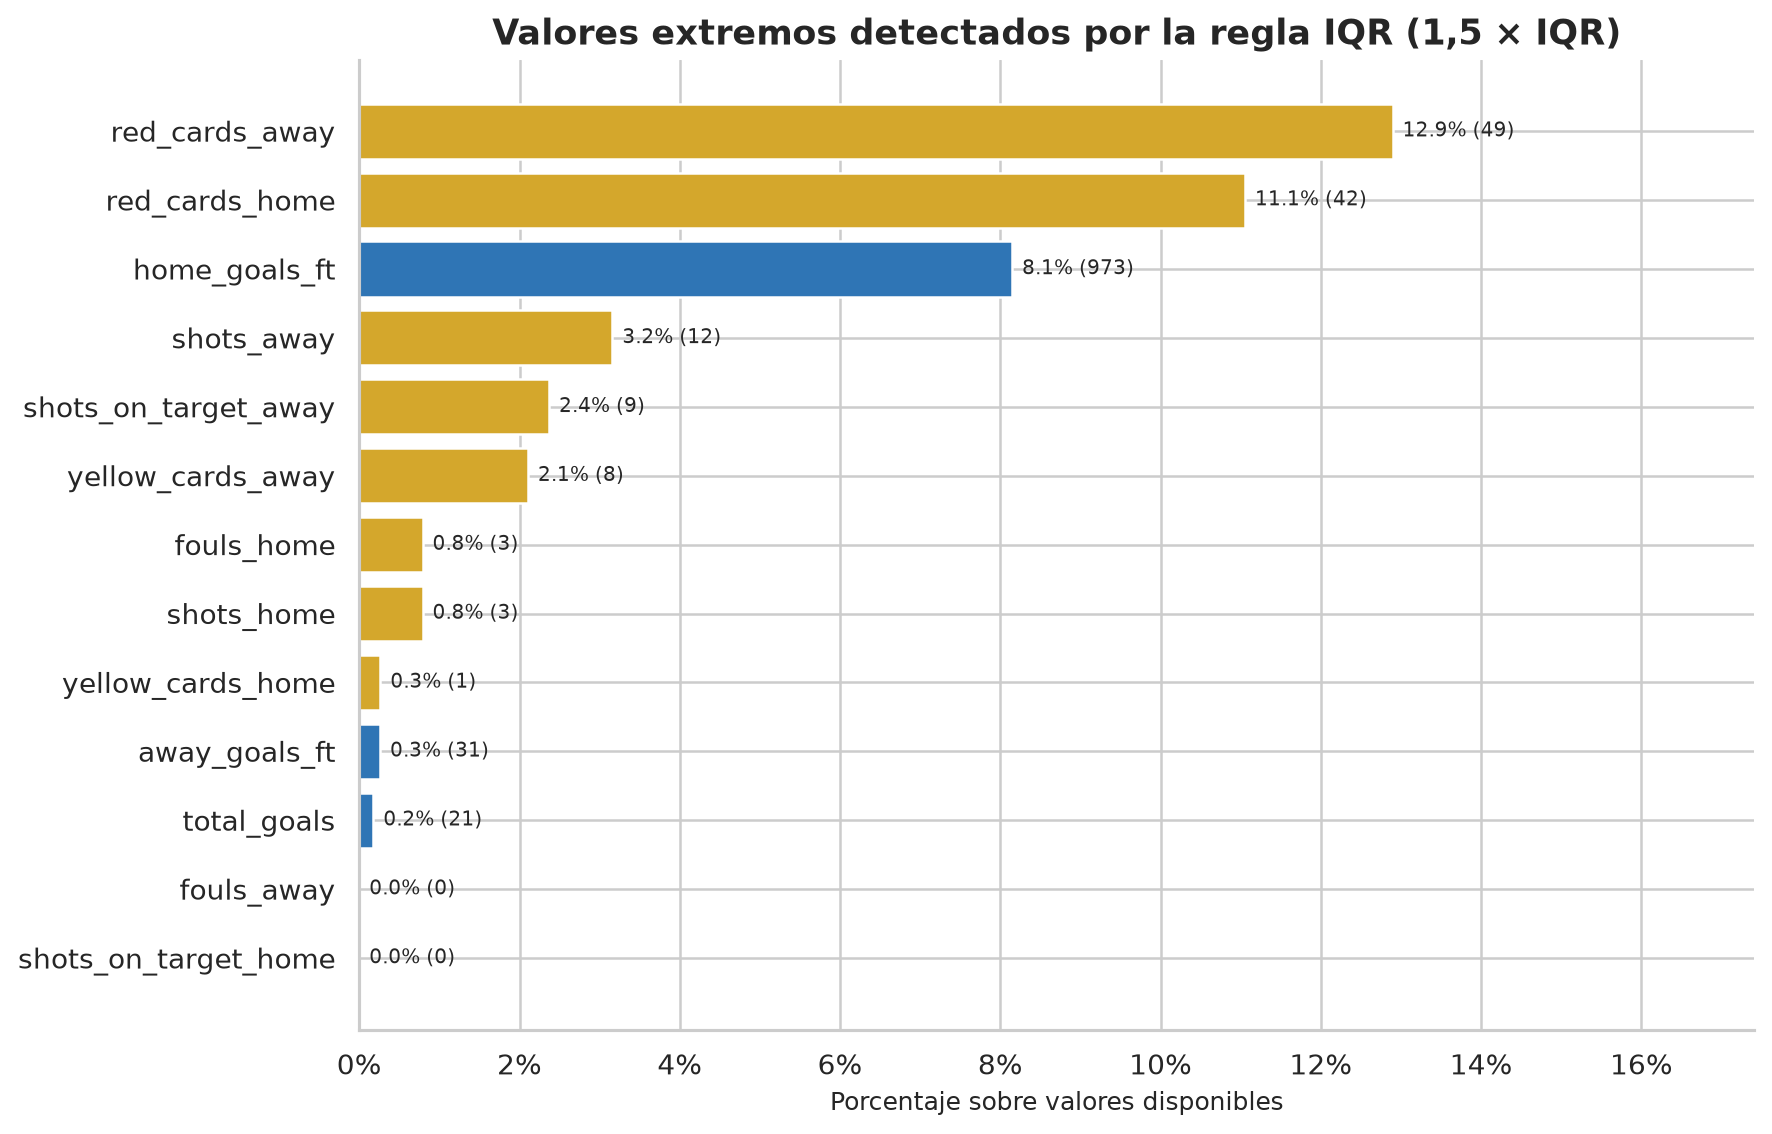

In [17]:
display(Image(filename=str(FIGURES_DIR / '11_outlier_profile.png'), width=900))

**Conclusión — `11_outlier_profile.png`:** El IQR se usa para identificar extremos, no para borrarlos automáticamente. La limpieza solo retira errores lógicos; los eventos deportivos raros permanecen.

## Conclusiones generales

El dataset limpio es adecuado para EDA y conserva 31 temporadas. Antes de modelar deben aprobarse licencia, target, métricas y partición temporal. Las variables postpartido tienen leakage crítico; una aplicación prepartido debería usar fecha, equipos, cuotas capturadas a tiempo y features históricas calculadas solo con encuentros anteriores.